# Four Objs Mask Area Consistency

Every physical object should have one mask area in a true top-down view. The overhead camera is off-axis, so masks pick up object sides and get bigger or smaller depending on where the object sits in the box.

This notebook measures how much each object's mask area, height and width vary. It also checks how much of that variation is explained by position, which would point to perspective, and how much is noise between repeat captures at the same position, which would point to segmentation.

# 1 Import

In [1]:
import json
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 220, "display.max_columns", 80)

REPO = Path.cwd().parent
DATA_DIR = REPO / "experiments" / "2026_09_27_gastronorm_four_objs"
CACHE = REPO / "notebooks" / "runs" / "91_mask_stats.parquet"


# 2 Per-Object Mask Stats

There is one row per object mask in `image/smasks/<object><k>.npy`, a full-res boolean mask at the cropped-overhead size of 1112x1365. The row stores the pixel area, the bounding-box height and width, and the centre of mass as (row, col). Stats are cached to parquet because a cold read of all the masks is about 10 GB.

In [2]:
def read_meta(path):
    meta = {}
    for line in path.read_text().splitlines():
        if line.strip(): meta.update(json.loads(line))
    return meta

def mask_stats(sample_dir):
    meta = read_meta(sample_dir / "metadata.jsonl")
    rows = []
    for f in sorted((sample_dir / "image" / "smasks").glob("*.npy")):
        m = np.load(f).astype(bool)
        r, c = np.nonzero(m)
        if len(r) == 0: continue
        rows.append(dict(sample_id=meta["sample_id"], position_id=meta["position_id"], speaker=meta.get("speaker"),
                         layout=meta.get("layout"), object=f.stem.rstrip("0123456789"), mask_file=str(f.relative_to(DATA_DIR)),
                         area=len(r), h=r.max() - r.min() + 1, w=c.max() - c.min() + 1, com_row=r.mean(), com_col=c.mean(),
                         H=m.shape[0], W=m.shape[1]))
    return rows

if CACHE.exists():
    df = pd.read_parquet(CACHE)
else:
    sample_dirs = sorted(p for p in (DATA_DIR / "samples").iterdir() if (p / "image" / "smasks").exists())
    with ThreadPoolExecutor(32) as ex: df = pd.DataFrame([r for rows in ex.map(mask_stats, sample_dirs) for r in rows])
    CACHE.parent.mkdir(exist_ok=True)
    df.to_parquet(CACHE)
df["n_objects"] = df.groupby("sample_id")["object"].transform("size")
df["y"], df["x"] = df.com_row / df.H, df.com_col / df.W  # box fractions
print(df.shape)
df.head()


(6820, 16)


,sample_id,position_id,speaker,layout,object,mask_file,area,h,w,com_row,com_col,H,W,n_objects,y,x
0,000020,5,1,red-cube-grid1,red-cube,samples/000020/image/smasks/red-cube0.npy,11581,113,106,823.633538,1140.890769,1112,1365,1,0.740678,0.835817
1,000021,5,2,red-cube-grid1,red-cube,samples/000021/image/smasks/red-cube0.npy,11581,113,106,823.633538,1140.890769,1112,1365,1,0.740678,0.835817
2,000022,5,3,red-cube-grid1,red-cube,samples/000022/image/smasks/red-cube0.npy,11581,113,106,823.633538,1140.890769,1112,1365,1,0.740678,0.835817
3,000023,5,4,red-cube-grid1,red-cube,samples/000023/image/smasks/red-cube0.npy,11581,113,106,823.633538,1140.890769,1112,1365,1,0.740678,0.835817
4,000024,5,7,red-cube-grid1,red-cube,samples/000024/image/smasks/red-cube0.npy,11581,113,106,823.633538,1140.890769,1112,1365,1,0.740678,0.835817


Drop the positions that every four_objs split ignores: hand in frame, mislabeled, whole-box segmentation, on the whiteboard, missing data. The list is `FOUR_OBJS_IGNORE_POSITIONS` in `src/model/dataset.py`.

Every speaker capture at a position reuses that position's single overhead image, so its masks are identical. To avoid counting the same mask five times, keep one row per (position, object).

Some masks are plainly broken segmentations: the whole box, the lid, or a sliver. A mask counts as broken when its area is more than 2x or less than 0.5x its object's median. The broken masks that are still left after the ignore list are shown below and left out of everything after this point.

In [3]:
import sys; sys.path.insert(0, str(REPO))
from src.model.dataset import FOUR_OBJS_IGNORE_POSITIONS

pos = df[~df.position_id.isin(FOUR_OBJS_IGNORE_POSITIONS)].drop_duplicates(["position_id", "object"]).copy()
pos["area_rel"] = pos.area / pos.groupby("object").area.transform("median")
broken = pos[(pos.area_rel > 2) | (pos.area_rel < .5)]
pos = pos.drop(broken.index)
print(f"{len(pos)} clean masks, {len(broken)} broken")
broken[["position_id", "sample_id", "layout", "object", "area", "area_rel", "h", "w"]]


1333 clean masks, 7 broken


,position_id,sample_id,layout,object,area,area_rel,h,w
6710,1242,006204,cylinder-100g,cylinder,1060,0.228966,41,40
6720,1244,006214,cylinder-100g,cylinder,1499,0.323793,54,39
6775,1255,006269,red-cube-lid,red-cube,1501361,129.965461,1112,1365
6785,1257,006279,red-cube-lid,red-cube,4050,0.350589,168,33
6795,1259,006289,red-cube-lid,red-cube,1495357,129.445724,1112,1365
6805,1261,006299,red-cube-lid,red-cube,4115,0.356215,168,34
6815,1263,006309,red-cube-lid,red-cube,4120,0.356648,168,35


# 3 Area Distribution Per Object

In [4]:
summary = pos.groupby("object").agg(n=("area", "size"), n_pos=("position_id", "nunique"),
                                   area_med=("area", "median"), area_p5=("area", lambda a: a.quantile(.05)),
                                   area_p95=("area", lambda a: a.quantile(.95)), area_cv=("area", lambda a: a.std() / a.mean()),
                                   h_cv=("h", lambda a: a.std() / a.mean()), w_cv=("w", lambda a: a.std() / a.mean()))
summary["p95/p5"] = summary.area_p95 / summary.area_p5
summary.sort_values("n", ascending=False).round(3)


,n,n_pos,area_med,area_p5,area_p95,area_cv,h_cv,w_cv,p95/p5
object,,,,,,,,,
red-cube,407,407,11552.0,10952.60,12021.20,0.028,0.093,0.109,1.098
vase,317,317,24575.0,24021.80,26193.40,0.029,0.017,0.034,1.090
candle,260,260,42021.0,37898.65,44413.55,0.050,0.019,0.035,1.172
soap dispenser,251,251,18232.0,17566.00,23589.50,0.108,0.072,0.157,1.343
green-cube,72,72,11419.0,10916.95,11848.85,0.029,0.030,0.025,1.085
cylinder,18,18,5513.5,3590.55,7837.50,0.301,0.208,0.176,2.183
coffee pot,8,8,26501.5,25371.15,28789.70,0.054,0.054,0.043,1.135


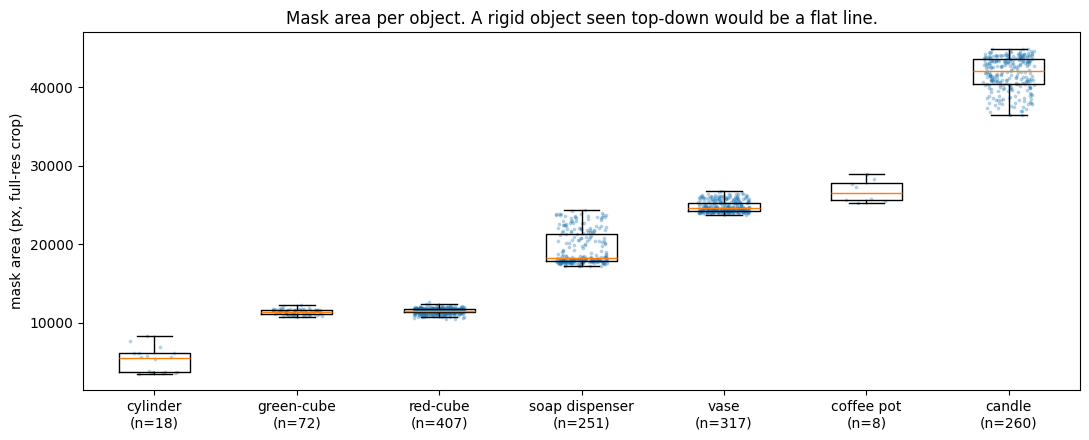

In [5]:
objs = summary.sort_values("area_med").index.tolist()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.boxplot([pos.loc[pos.object == o, "area"] for o in objs], showfliers=False, widths=.5)
for i, o in enumerate(objs, 1):
    a = pos.loc[pos.object == o, "area"]
    ax.scatter(i + np.random.uniform(-.18, .18, len(a)), a, s=3, alpha=.25, color="C0")
ax.set_xticks(range(1, len(objs) + 1), [f"{o}\n(n={summary.n[o]})" for o in objs])
ax.set_ylabel("mask area (px, full-res crop)")
ax.set_title("Mask area per object. A rigid object seen top-down would be a flat line.")
plt.tight_layout()


# 4 Area vs Position In The Box

If the variation is perspective, area should change smoothly with position: it should grow away from the point under the camera, where more of the object's side is visible. Each dot below is a mask centre of mass, coloured by area relative to that object's median.

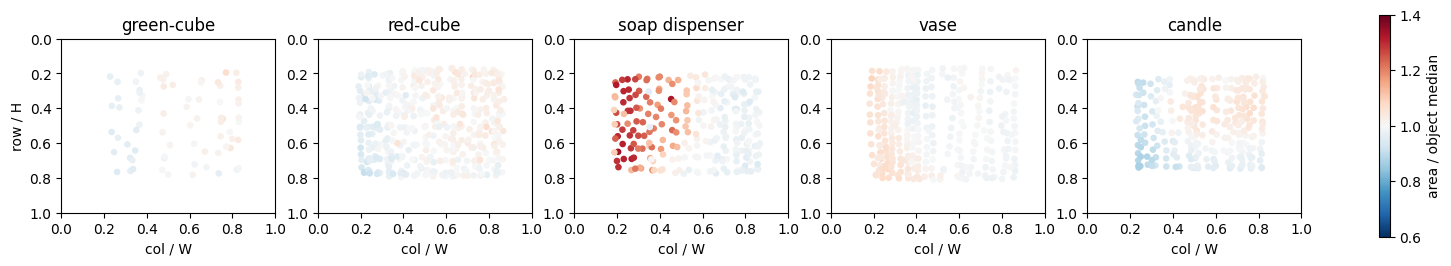

In [6]:
main = [o for o in objs if summary.n[o] >= 50]
fig, axes = plt.subplots(1, len(main), figsize=(4 * len(main), 3.6), squeeze=False)
for ax, o in zip(axes[0], main):
    d = pos[pos.object == o]
    sc = ax.scatter(d.x, d.y, c=d.area_rel, cmap="RdBu_r", vmin=.6, vmax=1.4, s=14)
    ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_aspect(1112 / 1365)
    ax.set_title(o); ax.set_xlabel("col / W")
axes[0, 0].set_ylabel("row / H")
fig.colorbar(sc, ax=axes[0].tolist(), label="area / object median", shrink=.8)


# 5 How Much Is Perspective?

For each object, fit log-area as a quadratic in (x, y). R² is the share of the area variance that a smooth camera geometry explains. The rest is segmentation noise or the object's orientation, since a rotated vase or soap dispenser shows a different footprint. `argmin` is the box position where the fit predicts the smallest mask, which is roughly the point under the camera.

There are no repeat images of the same placement, so segmentation noise can't be measured directly.

Only single-object samples are used here, so that occlusion and touching objects don't add noise.

In [7]:
def quad_fit(d):
    X = lambda x, y: np.column_stack([np.ones(len(x)), x, y, x**2, y**2, x * y])
    y = np.log(d.area.values)
    beta, *_ = np.linalg.lstsq(X(d.x, d.y), y, rcond=None)
    r2 = 1 - ((y - X(d.x, d.y) @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    g = np.linspace(0, 1, 101); gx, gy = [a.ravel() for a in np.meshgrid(g, g)]
    pred = X(gx, gy) @ beta
    return r2, (round(gx[pred.argmin()], 2), round(gy[pred.argmin()], 2))

single = pos[pos.n_objects == 1]
solo = [o for o in main if (single.object == o).sum() >= 50]
rows = []
for o in solo:
    d = single[single.object == o]
    r2, argmin = quad_fit(d)
    rows.append(dict(object=o, n=len(d), area_cv=d.area.std() / d.area.mean(), p95_over_p5=d.area.quantile(.95) / d.area.quantile(.05),
                     r2_quadratic_xy=r2, argmin_xy=argmin))
noise = pd.DataFrame(rows).set_index("object").round(3)
noise


,n,area_cv,p95_over_p5,r2_quadratic_xy,argmin_xy
object,,,,,
red-cube,286,0.028,1.089,0.635,"(0.0, 1.0)"
soap dispenser,251,0.108,1.343,0.806,"(0.98, 1.0)"
vase,268,0.030,1.091,0.777,"(0.63, 0.46)"
candle,260,0.050,1.172,0.916,"(0.0, 1.0)"


# 6 Outliers: Smallest, Median, Largest Masks

Each mask is cropped around its bounding box with some padding, next to the matching crop of the overhead photo. Look for masks that include the side face, masks that miss part of the object, and masks that bleed into the box wall or a shadow.

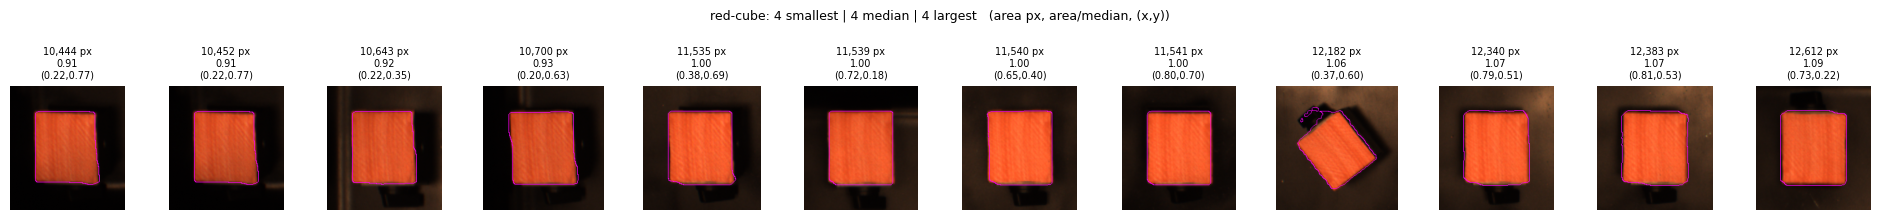

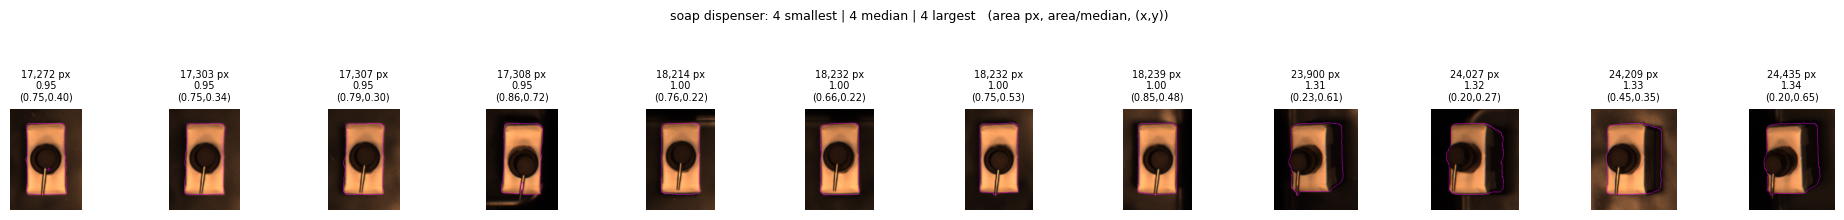

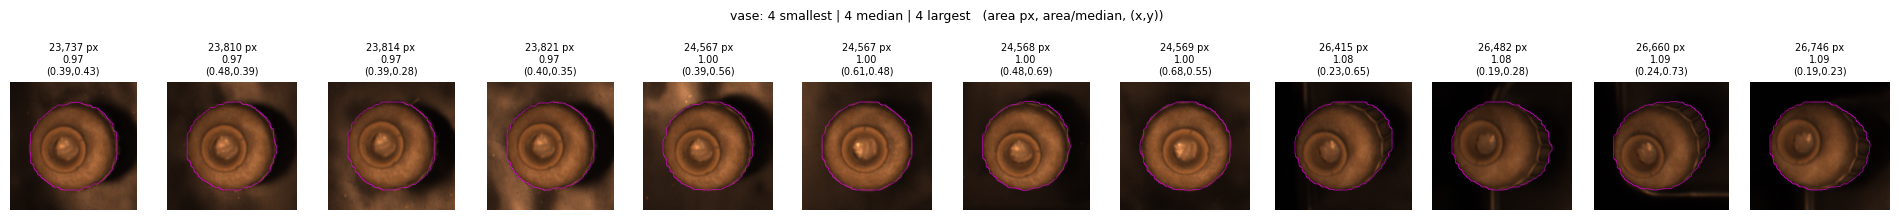

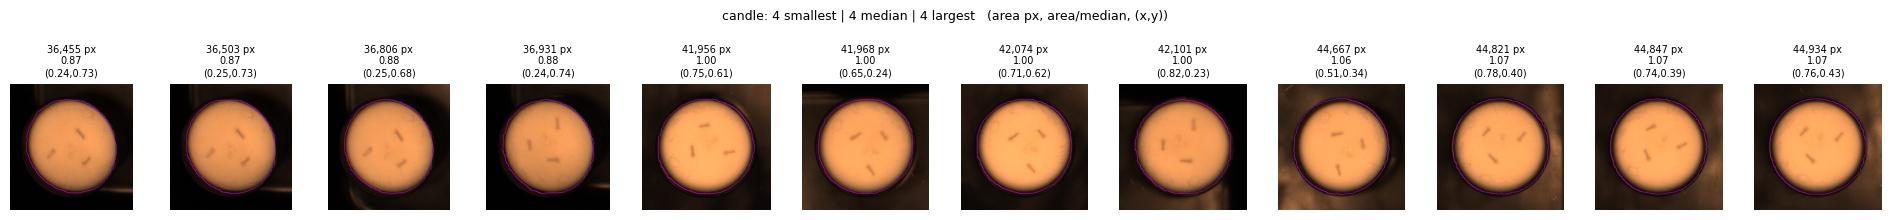

In [8]:
from PIL import Image

def crop_view(row, pad=40):
    m = np.load(DATA_DIR / row.mask_file).astype(bool)
    img = np.asarray(Image.open(DATA_DIR / Path(row.mask_file).parent.parent / "02_cropped_overhead.png").convert("RGB"))
    r, c = np.nonzero(m)
    r0, r1, c0, c1 = max(r.min() - pad, 0), r.max() + pad, max(c.min() - pad, 0), c.max() + pad
    out = img[r0:r1, c0:c1].astype(float) / 255
    edge = m[r0:r1, c0:c1] ^ np.pad(m[r0:r1, c0:c1], 1, mode="edge")[2:, 1:-1]  # mask outline (vertical edges)
    edge |= m[r0:r1, c0:c1] ^ np.pad(m[r0:r1, c0:c1], 1, mode="edge")[1:-1, 2:]
    out[edge] = [1, 0, 1]
    return out

N = 4
for o in solo:
    d = single[single.object == o].sort_values("area")
    picks = pd.concat([d.head(N), d.iloc[len(d) // 2 - N // 2: len(d) // 2 + N // 2], d.tail(N)])
    fig, axes = plt.subplots(1, len(picks), figsize=(1.6 * len(picks), 2.2))
    for ax, (_, r) in zip(axes, picks.iterrows()):
        ax.imshow(crop_view(r)); ax.axis("off")
        ax.set_title(f"{r.area:,} px\n{r.area / d.area.median():.2f}\n({r.x:.2f},{r.y:.2f})", fontsize=7)
    fig.suptitle(f"{o}: 4 smallest | 4 median | 4 largest   (area px, area/median, (x,y))", fontsize=9)
    plt.tight_layout(rect=(0, 0, 1, .88))


# 7 Canonical Mask Preview

This previews the proposed fix. For each object, take one canonical mask from the masks closest to the centre of the box, where the camera is most nearly overhead, and paste it at every sample's centre of mass. The table shows how far the canonical mask is from the real one (IoU) at full res and at the 64x64 training resolution.

In [9]:
def canonical_mask(d, k=10):
    # median-area mask among the k nearest to the box centre, cropped tight around its com
    near = d.assign(r=np.hypot(d.x - .5, d.y - .5)).nsmallest(k, "r")
    row = near.iloc[(near.area - near.area.median()).abs().argmin()]
    m = np.load(DATA_DIR / row.mask_file).astype(bool)
    r, c = np.nonzero(m)
    return m[r.min():r.max() + 1, c.min():c.max() + 1], (row.com_row - r.min(), row.com_col - c.min()), row

def paste(canon, canon_com, com_row, com_col, H, W):
    out = np.zeros((H, W), bool)
    r0, c0 = int(round(com_row - canon_com[0])), int(round(com_col - canon_com[1]))
    h, w = canon.shape
    rs, cs = slice(max(r0, 0), min(r0 + h, H)), slice(max(c0, 0), min(c0 + w, W))
    out[rs, cs] = canon[rs.start - r0: rs.stop - r0, cs.start - c0: cs.stop - c0]
    return out

def down(m, s=64):
    return np.asarray(Image.fromarray(m.astype(np.uint8) * 255).resize((s, s), Image.BILINEAR)) > 127

iou = lambda a, b: (a & b).sum() / max((a | b).sum(), 1)
rows = []
for o in solo:
    d = single[single.object == o]
    canon, ccom, crow = canonical_mask(d)
    for _, r in d.iterrows():
        real = np.load(DATA_DIR / r.mask_file).astype(bool)
        fake = paste(canon, ccom, r.com_row, r.com_col, r.H, r.W)
        rows.append(dict(object=o, x=r.x, y=r.y, iou_full=iou(real, fake), iou_64=iou(down(real), down(fake))))
canon_iou = pd.DataFrame(rows)
canon_iou.groupby("object")[["iou_full", "iou_64"]].describe(percentiles=[.1, .5]).round(3)


iou_full                                         iou_64                                        
                  count   mean    std    min    10%    50%  max  count   mean    std    min    10%    50%  max
object                                                                                                        
candle            260.0  0.947  0.039  0.835  0.883  0.960  1.0  260.0  0.950  0.044  0.832  0.881  0.966  1.0
red-cube          286.0  0.913  0.079  0.701  0.733  0.943  1.0  286.0  0.935  0.088  0.658  0.768  0.971  1.0
soap dispenser    251.0  0.868  0.080  0.396  0.839  0.870  1.0  251.0  0.879  0.128  0.338  0.710  0.925  1.0
vase              268.0  0.951  0.027  0.882  0.905  0.964  1.0  268.0  0.956  0.040  0.833  0.900  0.969  1.0

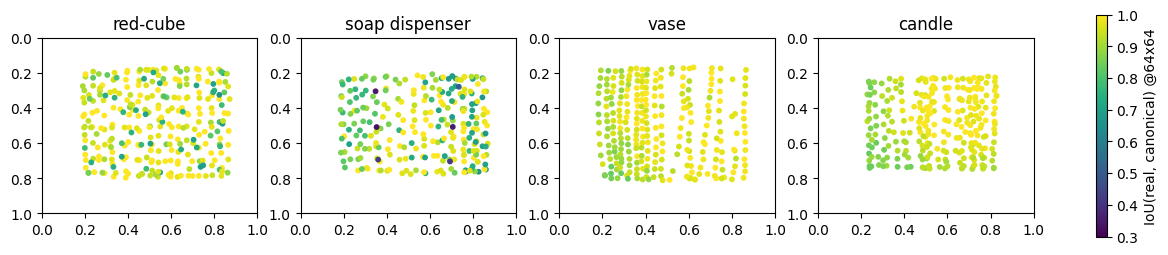

In [10]:
fig, axes = plt.subplots(1, len(solo), figsize=(4 * len(solo), 3.6), squeeze=False)
for ax, o in zip(axes[0], solo):
    d = canon_iou[canon_iou.object == o]
    sc = ax.scatter(d.x, d.y, c=d.iou_64, cmap="viridis", vmin=.3, vmax=1, s=10)
    ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_aspect(1112 / 1365); ax.set_title(o)
fig.colorbar(sc, ax=axes[0].tolist(), label="IoU(real, canonical) @64x64", shrink=.8)


# 8 Findings (2026-10-01, after the split_2 ignore list)

- **Most positions are already consistent.** Area CV is about 3% for the cubes and the vase, 5% for the candle, and 11% for the soap dispenser. At 64x64 a cube is only about 31 px, so a 5% area change moves about one boundary pixel.
- **Once the bad positions are gone, most of what remains is position-driven.** R² is 0.64 for red-cube, 0.78 for vase, 0.92 for candle and 0.81 for soap dispenser. Only the soap dispenser changes a lot, because its mask includes the side face in the left ~40% of the box (+21% median area).
- **Pasting a canonical mask changes the ground truth only a little.** The median IoU between the real and canonical mask at 64x64 is 0.93-0.97, and the 10th percentile is 0.71-0.90, with the soap dispenser lowest.
- **7 broken masks are still not on the ignore list.** These are red-cube-lid positions 1255-1263 (whole box or sliver) and cylinder-100g positions 1242 and 1244 (sliver). They are all eval-only layouts.
- **A canonical mask has to keep rotation**, because cubes and the soap dispenser are placed at different angles.